In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configurar estilo
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Carregamento dos Dados

In [3]:
# Carregar resultados
singlechannel_df = pd.read_csv('results/singlechannel_adversarial_results.csv')
multichannel_df = pd.read_csv('results/multichannel_adversarial_results.csv')

print("="*60)
print("RESULTADOS SINGLECHANNEL")
print("="*60)
print(f"Total de amostras: {len(singlechannel_df)}")
print(f"Colunas: {list(singlechannel_df.columns)}")
print("\n")

print("="*60)
print("RESULTADOS MULTICHANNEL")
print("="*60)
print(f"Total de amostras: {len(multichannel_df)}")
print(f"Colunas: {list(multichannel_df.columns)}")

RESULTADOS SINGLECHANNEL
Total de amostras: 1653
Colunas: ['sample_idx', 'fold', 'real_class', 'initial_pred', 'initial_correct', 'fooled_class', 'relative_robustness', 'perturbation_norm', 'original_norm', 'num_iterations', 'success']


RESULTADOS MULTICHANNEL
Total de amostras: 1653
Colunas: ['sample_idx', 'fold', 'real_class', 'initial_pred', 'initial_correct', 'fooled_class', 'relative_robustness', 'perturbation_norm', 'original_norm', 'pert_norm_logmel', 'pert_norm_delta', 'pert_norm_delta2', 'pert_norm_harmonic', 'pert_norm_percussive', 'most_perturbed_channel', 'num_iterations', 'success']


## 2. Estatísticas Gerais

In [4]:
# Estatísticas Singlechannel
print("="*60)
print("ESTATÍSTICAS - SINGLECHANNEL")
print("="*60)

sc_correctly_classified = singlechannel_df['initial_correct'].sum()
sc_total = len(singlechannel_df)
sc_successfully_fooled = singlechannel_df['success'].sum()
sc_attack_success_rate = (sc_successfully_fooled / sc_correctly_classified * 100) if sc_correctly_classified > 0 else 0

print(f"Amostras corretamente classificadas: {sc_correctly_classified}/{sc_total} ({sc_correctly_classified/sc_total*100:.2f}%)")
print(f"Ataques bem-sucedidos: {sc_successfully_fooled}/{sc_correctly_classified} ({sc_attack_success_rate:.2f}%)")
print(f"Média de iterações: {singlechannel_df[singlechannel_df['success']]['num_iterations'].mean():.2f}")
print(f"Média de robustez relativa: {singlechannel_df[singlechannel_df['success']]['relative_robustness'].mean():.6f}")
print(f"Média de norma de perturbação: {singlechannel_df[singlechannel_df['success']]['perturbation_norm'].mean():.2f}")

print("\n")

# Estatísticas Multichannel
print("="*60)
print("ESTATÍSTICAS - MULTICHANNEL")
print("="*60)

mc_correctly_classified = multichannel_df['initial_correct'].sum()
mc_total = len(multichannel_df)
mc_successfully_fooled = multichannel_df['success'].sum()
mc_attack_success_rate = (mc_successfully_fooled / mc_correctly_classified * 100) if mc_correctly_classified > 0 else 0

print(f"Amostras corretamente classificadas: {mc_correctly_classified}/{mc_total} ({mc_correctly_classified/mc_total*100:.2f}%)")
print(f"Ataques bem-sucedidos: {mc_successfully_fooled}/{mc_correctly_classified} ({mc_attack_success_rate:.2f}%)")
print(f"Média de iterações: {multichannel_df[multichannel_df['success']]['num_iterations'].mean():.2f}")
print(f"Média de robustez relativa: {multichannel_df[multichannel_df['success']]['relative_robustness'].mean():.6f}")
print(f"Média de norma de perturbação: {multichannel_df[multichannel_df['success']]['perturbation_norm'].mean():.2f}")

ESTATÍSTICAS - SINGLECHANNEL
Amostras corretamente classificadas: 1194/1653 (72.23%)
Ataques bem-sucedidos: 1194/1194 (100.00%)
Média de iterações: 2.02
Média de robustez relativa: 0.011356
Média de norma de perturbação: 22.41


ESTATÍSTICAS - MULTICHANNEL
Amostras corretamente classificadas: 1227/1653 (74.23%)
Ataques bem-sucedidos: 1227/1227 (100.00%)
Média de iterações: 2.24
Média de robustez relativa: 0.003774
Média de norma de perturbação: 20.15


## 3. Comparação Visual: Singlechannel vs Multichannel

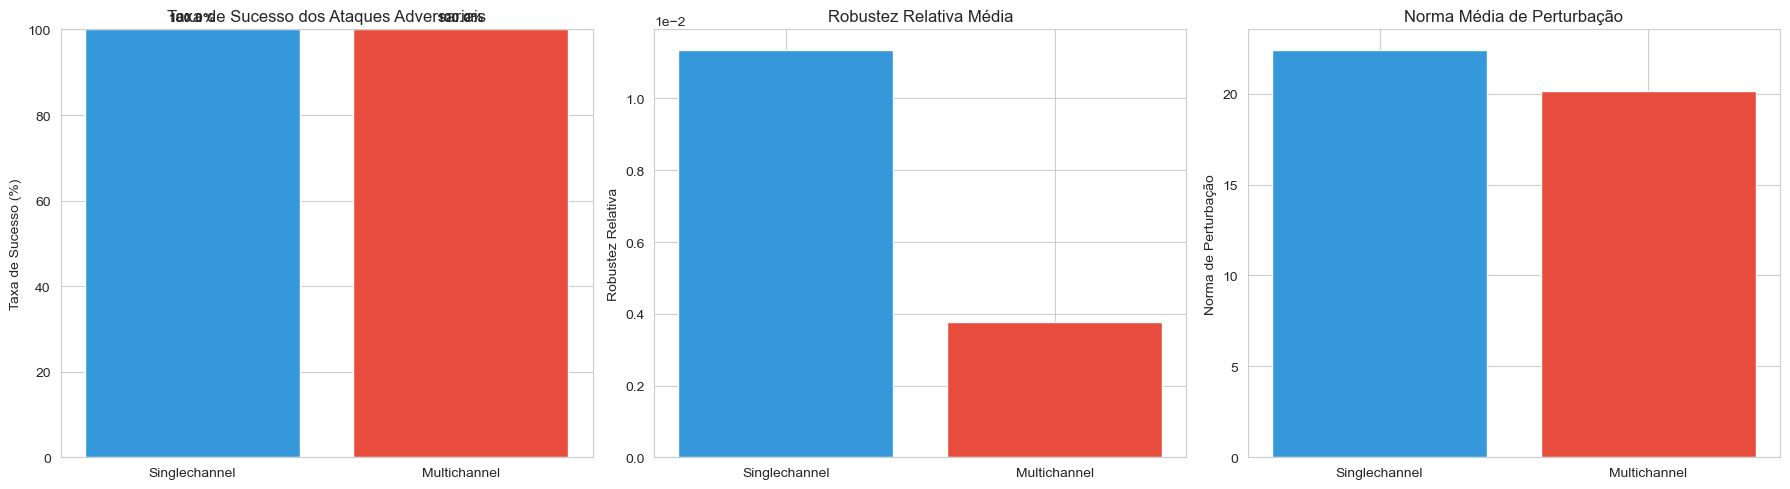

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Taxa de sucesso dos ataques
attack_rates = [sc_attack_success_rate, mc_attack_success_rate]
axes[0].bar(['Singlechannel', 'Multichannel'], attack_rates, color=['#3498db', '#e74c3c'])
axes[0].set_ylabel('Taxa de Sucesso (%)')
axes[0].set_title('Taxa de Sucesso dos Ataques Adversariais')
axes[0].set_ylim([0, 100])
for i, v in enumerate(attack_rates):
    axes[0].text(i, v + 2, f'{v:.1f}%', ha='center', fontweight='bold')

# Robustez relativa média
sc_rob = singlechannel_df[singlechannel_df['success']]['relative_robustness'].mean()
mc_rob = multichannel_df[multichannel_df['success']]['relative_robustness'].mean()
axes[1].bar(['Singlechannel', 'Multichannel'], [sc_rob, mc_rob], color=['#3498db', '#e74c3c'])
axes[1].set_ylabel('Robustez Relativa')
axes[1].set_title('Robustez Relativa Média')
axes[1].ticklabel_format(style='scientific', axis='y', scilimits=(0,0))

# Norma de perturbação média
sc_pert = singlechannel_df[singlechannel_df['success']]['perturbation_norm'].mean()
mc_pert = multichannel_df[multichannel_df['success']]['perturbation_norm'].mean()
axes[2].bar(['Singlechannel', 'Multichannel'], [sc_pert, mc_pert], color=['#3498db', '#e74c3c'])
axes[2].set_ylabel('Norma de Perturbação')
axes[2].set_title('Norma Média de Perturbação')

plt.tight_layout()
plt.show()

## 4. Análise por Classe

In [6]:
# Análise por classe - Singlechannel
sc_class_analysis = singlechannel_df[singlechannel_df['initial_correct']].groupby('real_class').agg({
    'success': ['sum', 'count', 'mean'],
    'relative_robustness': 'mean',
    'perturbation_norm': 'mean'
}).round(4)

sc_class_analysis.columns = ['Ataques Sucesso', 'Total', 'Taxa Sucesso', 'Robustez Média', 'Pert. Média']
sc_class_analysis = sc_class_analysis.sort_values('Taxa Sucesso', ascending=False)

print("="*60)
print("ANÁLISE POR CLASSE - SINGLECHANNEL")
print("="*60)
print(sc_class_analysis)
print("\n")

# Análise por classe - Multichannel
mc_class_analysis = multichannel_df[multichannel_df['initial_correct']].groupby('real_class').agg({
    'success': ['sum', 'count', 'mean'],
    'relative_robustness': 'mean',
    'perturbation_norm': 'mean'
}).round(4)

mc_class_analysis.columns = ['Ataques Sucesso', 'Total', 'Taxa Sucesso', 'Robustez Média', 'Pert. Média']
mc_class_analysis = mc_class_analysis.sort_values('Taxa Sucesso', ascending=False)

print("="*60)
print("ANÁLISE POR CLASSE - MULTICHANNEL")
print("="*60)
print(mc_class_analysis)

ANÁLISE POR CLASSE - SINGLECHANNEL
                  Ataques Sucesso  Total  Taxa Sucesso  Robustez Média  \
real_class                                                               
air_conditioner                38     38           1.0          0.0028   
car_horn                       58     58           1.0          0.0063   
children_playing              180    180           1.0          0.0051   
dog_bark                      122    122           1.0          0.0077   
drilling                      164    164           1.0          0.0131   
engine_idling                  96     96           1.0          0.0038   
gun_shot                       61     61           1.0          0.0049   
jackhammer                    166    166           1.0          0.0322   
siren                         125    125           1.0          0.0103   
street_music                  184    184           1.0          0.0096   

                  Pert. Média  
real_class                     
air_conditio

## 5. Classes Mais Vulneráveis

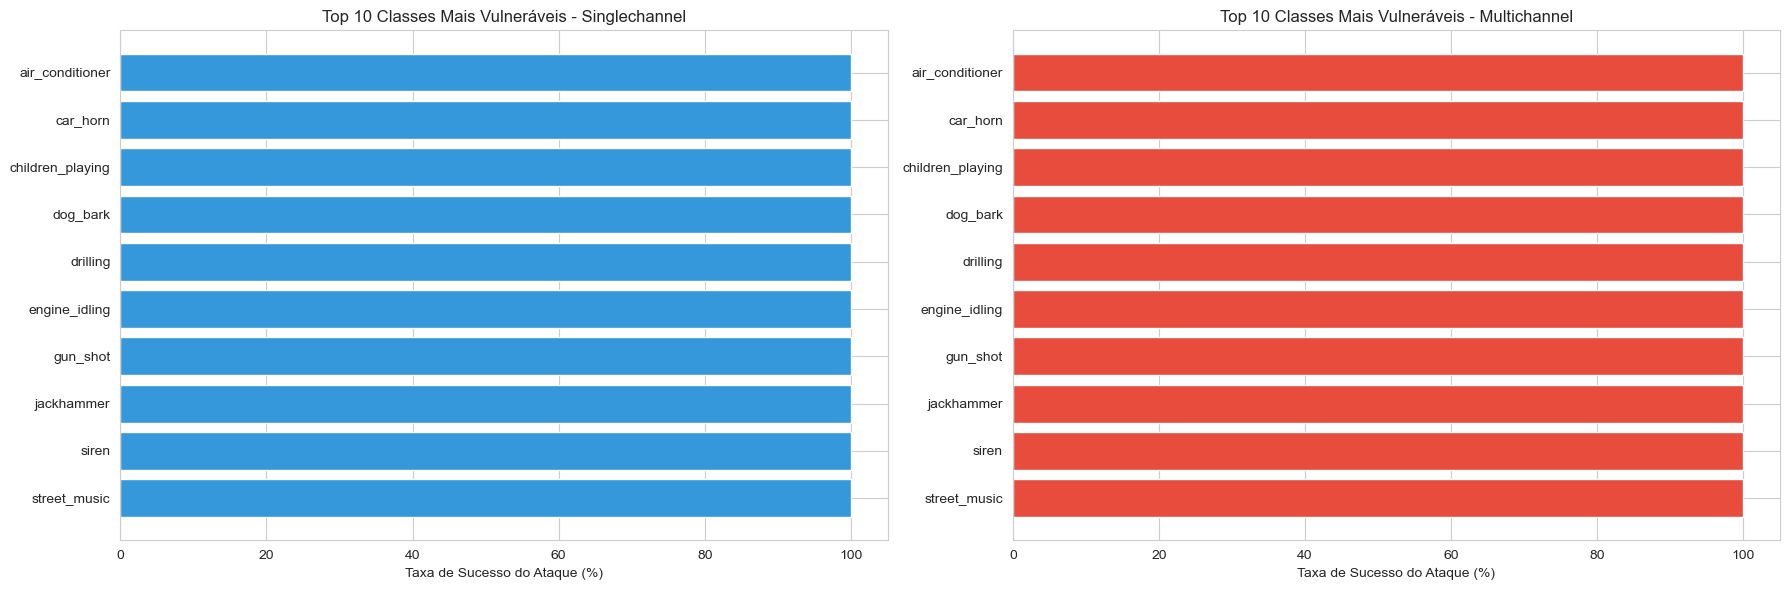

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Singlechannel
sc_top = sc_class_analysis.nlargest(10, 'Taxa Sucesso')[['Taxa Sucesso']].reset_index()
axes[0].barh(sc_top['real_class'], sc_top['Taxa Sucesso'] * 100, color='#3498db')
axes[0].set_xlabel('Taxa de Sucesso do Ataque (%)')
axes[0].set_title('Top 10 Classes Mais Vulneráveis - Singlechannel')
axes[0].invert_yaxis()

# Multichannel
mc_top = mc_class_analysis.nlargest(10, 'Taxa Sucesso')[['Taxa Sucesso']].reset_index()
axes[1].barh(mc_top['real_class'], mc_top['Taxa Sucesso'] * 100, color='#e74c3c')
axes[1].set_xlabel('Taxa de Sucesso do Ataque (%)')
axes[1].set_title('Top 10 Classes Mais Vulneráveis - Multichannel')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

## 6. Distribuição de Iterações

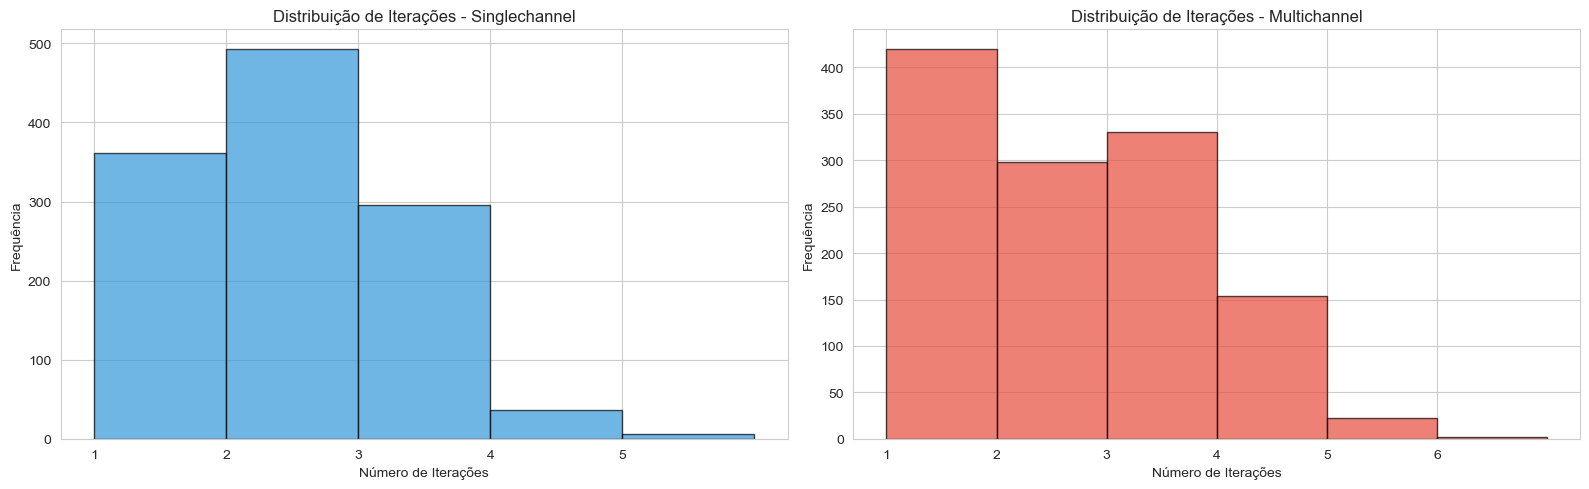

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Singlechannel
sc_success = singlechannel_df[singlechannel_df['success']]
axes[0].hist(sc_success['num_iterations'], bins=range(1, sc_success['num_iterations'].max() + 2), 
             color='#3498db', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Número de Iterações')
axes[0].set_ylabel('Frequência')
axes[0].set_title('Distribuição de Iterações - Singlechannel')
axes[0].set_xticks(range(1, sc_success['num_iterations'].max() + 1))

# Multichannel
mc_success = multichannel_df[multichannel_df['success']]
axes[1].hist(mc_success['num_iterations'], bins=range(1, mc_success['num_iterations'].max() + 2), 
             color='#e74c3c', edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Número de Iterações')
axes[1].set_ylabel('Frequência')
axes[1].set_title('Distribuição de Iterações - Multichannel')
axes[1].set_xticks(range(1, mc_success['num_iterations'].max() + 1))

plt.tight_layout()
plt.show()

## 7. Canal Mais Perturbado (Multichannel)

Distribuição do Canal Mais Perturbado:
most_perturbed_channel
Delta          1219
Delta-Delta       8
Name: count, dtype: int64



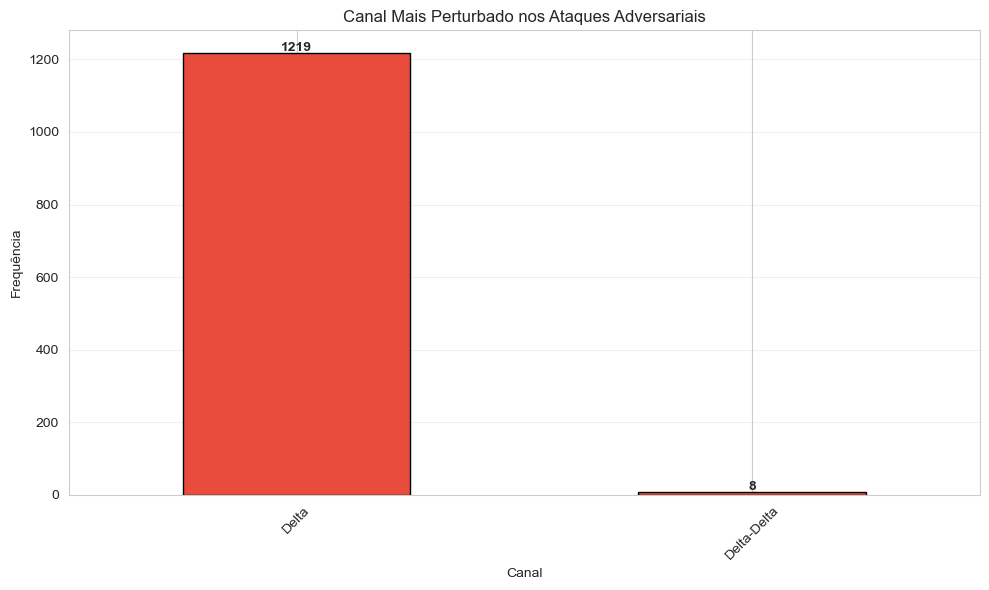

In [9]:
# Análise do canal mais perturbado
mc_success = multichannel_df[multichannel_df['success']]
channel_counts = mc_success['most_perturbed_channel'].value_counts()

print("Distribuição do Canal Mais Perturbado:")
print(channel_counts)
print()

# Visualização
plt.figure(figsize=(10, 6))
channel_counts.plot(kind='bar', color='#e74c3c', edgecolor='black')
plt.xlabel('Canal')
plt.ylabel('Frequência')
plt.title('Canal Mais Perturbado nos Ataques Adversariais')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)

# Adicionar valores no topo das barras
for i, v in enumerate(channel_counts.values):
    plt.text(i, v + 5, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

## 8. Principais Confusões (Fooled Classes)

In [10]:
# Top confusões - Singlechannel
sc_success = singlechannel_df[singlechannel_df['success']]
sc_confusion = sc_success.groupby(['real_class', 'fooled_class']).size().reset_index(name='count')
sc_confusion = sc_confusion.sort_values('count', ascending=False).head(15)

print("="*60)
print("TOP 15 CONFUSÕES - SINGLECHANNEL")
print("="*60)
print(sc_confusion.to_string(index=False))
print("\n")

# Top confusões - Multichannel
mc_success = multichannel_df[multichannel_df['success']]
mc_confusion = mc_success.groupby(['real_class', 'fooled_class']).size().reset_index(name='count')
mc_confusion = mc_confusion.sort_values('count', ascending=False).head(15)

print("="*60)
print("TOP 15 CONFUSÕES - MULTICHANNEL")
print("="*60)
print(mc_confusion.to_string(index=False))

TOP 15 CONFUSÕES - SINGLECHANNEL
      real_class     fooled_class  count
children_playing     street_music    104
        drilling       jackhammer    103
    street_music children_playing     71
           siren children_playing     66
    street_music         car_horn     60
   engine_idling       jackhammer     57
      jackhammer         drilling     52
      jackhammer         car_horn     41
      jackhammer            siren     41
        dog_bark children_playing     39
children_playing            siren     37
   engine_idling  air_conditioner     33
        dog_bark         gun_shot     33
        drilling children_playing     33
    street_music       jackhammer     31


TOP 15 CONFUSÕES - MULTICHANNEL
      real_class     fooled_class  count
      jackhammer    engine_idling    133
children_playing         dog_bark    122
        dog_bark children_playing    110
   engine_idling       jackhammer     67
           siren         dog_bark     67
    street_music children_playi

## 9. Conclusões

### Singlechannel vs Multichannel

Os resultados mostram as diferenças entre os modelos singlechannel e multichannel em termos de:

1. **Taxa de Sucesso dos Ataques**: Indica qual modelo é mais robusto
2. **Robustez Relativa**: Menor valor = mais vulnerável
3. **Norma de Perturbação**: Magnitude da perturbação necessária para enganar o modelo
4. **Classes Vulneráveis**: Quais sons são mais fáceis de atacar
5. **Iterações Necessárias**: Complexidade do ataque

### Canal Mais Perturbado (Multichannel)

A análise do canal mais perturbado revela qual representação de áudio (LogMel, Delta, Delta2, Harmonic, Percussive) é mais sensível aos ataques adversariais.